# Лабораторная работа: Предобработка данных

**Задание:** Выбрать набор данных с категориальными признаками и пропусками. Выполнить:
1. Обработку пропусков в данных
2. Кодирование категориальных признаков
3. Масштабирование данных

**Датасет:** [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) — предсказание инсульта. Содержит категориальные признаки и пропуски в **bmi**.

## 1. Загрузка данных и первичный анализ

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler

%matplotlib inline
sns.set(style="ticks")

In [2]:
import os
fname = 'healthcare-dataset-stroke-data.csv'
df = pd.read_csv(fname)

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
print('Размер:', df.shape)
print('\nТипы столбцов:')
print(df.dtypes)
print('\nИнформация о датасете:')
df.info()

Размер: (5110, 12)

Типы столбцов:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Столбцы с пропусками:')
print(missing)
print('\nДоля пропусков (%):')
print((missing / len(df) * 100).round(2))

Столбцы с пропусками:
bmi    201
dtype: int64

Доля пропусков (%):
bmi    3.93
dtype: float64


## 2. Обработка пропусков в данных

**Подходы:** удаление строк/столбцов или заполнение пропусков (медиана, среднее, мода, константа). Используем **SimpleImputer** из sklearn.

In [6]:
df_work = df.copy()

print('Числовые столбцы с пропусками:', df_work.select_dtypes(include=[np.number]).columns[df_work.select_dtypes(include=[np.number]).isnull().any()].tolist())
print('Категориальные столбцы с пропусками:', df_work.select_dtypes(include=['object', 'category']).columns[df_work.select_dtypes(include=['object', 'category']).isnull().any()].tolist())

Числовые столбцы с пропусками: ['bmi']
Категориальные столбцы с пропусками: []


In [7]:
imputer_bmi = SimpleImputer(strategy='median')
df_work['bmi'] = imputer_bmi.fit_transform(df_work[['bmi']])

print('Пропуски после обработки:')
missing_after = df_work.isnull().sum()[df_work.isnull().sum() > 0]
print(missing_after if len(missing_after) > 0 else 'Нет пропусков')

Пропуски после обработки:
Нет пропусков


## 3. Кодирование категориальных признаков

Алгоритмы машинного обучения работают с числами. **Label Encoding** — присвоение каждой категории целого числа (для порядковых признаков). **One-Hot Encoding** — создание бинарных столбцов для каждой категории (для номинальных признаков без порядка).

In [8]:
cat_cols = df_work.select_dtypes(include=['object', 'category']).columns.tolist()
print('Категориальные столбцы:', cat_cols)
for c in cat_cols:
    print(f'\n{c}:', df_work[c].unique())

Категориальные столбцы: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

gender: ['Male' 'Female' 'Other']

ever_married: ['Yes' 'No']

work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Residence_type: ['Urban' 'Rural']

smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


### 3.1 Label Encoding (для бинарных признаков: ever_married, Residence_type)

In [9]:
for col in ['ever_married', 'Residence_type']:
    le = LabelEncoder()
    df_work[f'{col}_encoded'] = le.fit_transform(df_work[col].astype(str))
    print(f'{col}:', dict(zip(le.classes_, le.transform(le.classes_))))
print(df_work[['ever_married', 'ever_married_encoded', 'Residence_type', 'Residence_type_encoded']].drop_duplicates().head())

ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}
   ever_married  ever_married_encoded Residence_type  Residence_type_encoded
0           Yes                     1          Urban                       1
1           Yes                     1          Rural                       0
7            No                     0          Urban                       1
35           No                     0          Rural                       0


### 3.2 One-Hot Encoding (для номинальных признаков: work_type, gender, smoking_status)

In [10]:
cols_for_onehot = ['work_type', 'gender', 'smoking_status']
df_onehot = df_work[cols_for_onehot].astype(str)
encoder = OneHotEncoder(sparse_output=False, drop='first')
onehot_arr = encoder.fit_transform(df_onehot)
onehot_names = encoder.get_feature_names_out(cols_for_onehot)
df_onehot_encoded = pd.DataFrame(onehot_arr, columns=onehot_names, index=df_work.index)
print('Новые столбцы:')
print(df_onehot_encoded.head())

Новые столбцы:
   work_type_Never_worked  work_type_Private  work_type_Self-employed  \
0                     0.0                1.0                      0.0   
1                     0.0                0.0                      1.0   
2                     0.0                1.0                      0.0   
3                     0.0                1.0                      0.0   
4                     0.0                0.0                      1.0   

   work_type_children  gender_Male  gender_Other  \
0                 0.0          1.0           0.0   
1                 0.0          0.0           0.0   
2                 0.0          1.0           0.0   
3                 0.0          0.0           0.0   
4                 0.0          0.0           0.0   

   smoking_status_formerly smoked  smoking_status_never smoked  \
0                             1.0                          0.0   
1                             0.0                          1.0   
2                             0.0  

In [11]:
df_encoded = df_work.drop(columns=cols_for_onehot + ['ever_married', 'Residence_type']).copy()
df_encoded = pd.concat([df_encoded, df_onehot_encoded], axis=1)

feature_cols = [c for c in df_encoded.select_dtypes(include=[np.number]).columns if c not in ('id', 'stroke')]
print('Итоговые признаки для модели:', feature_cols)

Итоговые признаки для модели: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'ever_married_encoded', 'Residence_type_encoded', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'gender_Male', 'gender_Other', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


## 4. Масштабирование данных

Масштабирование приводит признаки к сопоставимым диапазонам, что важно для методов, чувствительных к масштабу.

- **StandardScaler** — приведение к среднему 0 и дисперсии 1 (z-score).
- **MinMaxScaler** — приведение к диапазону [0, 1].

In [12]:
# Матрица признаков
X = df_encoded[feature_cols].copy()
show_cols = ['age', 'avg_glucose_level', 'bmi']
print('Исходные статистики:')
print(X[show_cols].describe())

Исходные статистики:
               age  avg_glucose_level          bmi
count  5110.000000        5110.000000  5110.000000
mean     43.226614         106.147677    28.862035
std      22.612647          45.283560     7.699562
min       0.080000          55.120000    10.300000
25%      25.000000          77.245000    23.800000
50%      45.000000          91.885000    28.100000
75%      61.000000         114.090000    32.800000
max      82.000000         271.740000    97.600000


### 4.1 StandardScaler (среднее = 0, стандартное отклонение = 1)

In [13]:
scaler_std = StandardScaler()
X_scaled_std = scaler_std.fit_transform(X)
X_scaled_std_df = pd.DataFrame(X_scaled_std, columns=feature_cols, index=X.index)
print('После StandardScaler (среднее ≈ 0, std ≈ 1):')
print(X_scaled_std_df[show_cols].describe())

После StandardScaler (среднее ≈ 0, std ≈ 1):
                age  avg_glucose_level           bmi
count  5.110000e+03       5.110000e+03  5.110000e+03
mean   5.005781e-17       1.001156e-16 -4.449583e-17
std    1.000098e+00       1.000098e+00  1.000098e+00
min   -1.908261e+00      -1.126958e+00 -2.411027e+00
25%   -8.061152e-01      -6.383223e-01 -6.575089e-01
50%    7.843218e-02      -3.149945e-01 -9.898092e-02
75%    7.860701e-01       1.754080e-01  5.115031e-01
max    1.714845e+00       3.657145e+00  8.928390e+00


### 4.2 MinMaxScaler (диапазон [0, 1])

In [14]:
scaler_minmax = MinMaxScaler()
X_scaled_minmax = scaler_minmax.fit_transform(X)
X_scaled_minmax_df = pd.DataFrame(X_scaled_minmax, columns=feature_cols, index=X.index)
print('После MinMaxScaler (min=0, max=1):')
print(X_scaled_minmax_df[show_cols].describe())

После MinMaxScaler (min=0, max=1):
               age  avg_glucose_level          bmi
count  5110.000000        5110.000000  5110.000000
mean      0.526692           0.235563     0.212624
std       0.276033           0.209046     0.088197
min       0.000000           0.000000     0.000000
25%       0.304199           0.102137     0.154639
50%       0.548340           0.169721     0.203895
75%       0.743652           0.272228     0.257732
max       1.000000           1.000000     1.000000


### Сравнение до и после масштабирования

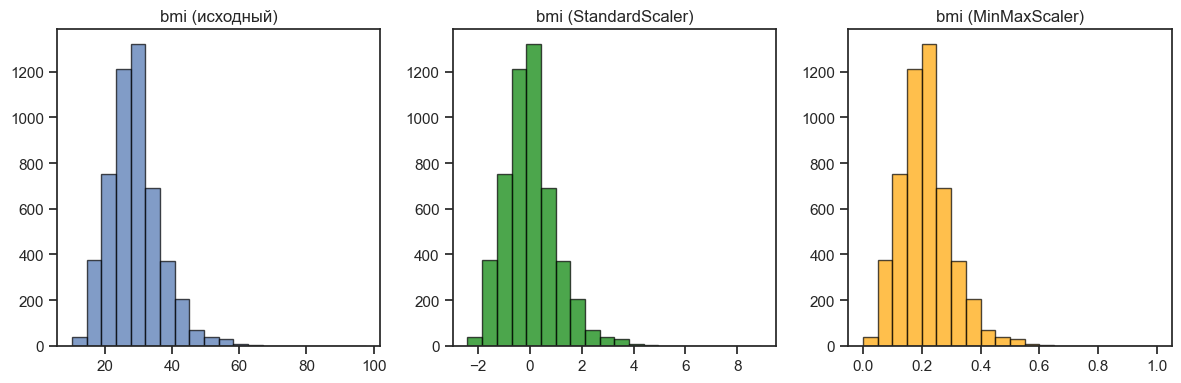

In [15]:
col_plot = 'bmi'
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(X[col_plot].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title(f'{col_plot} (исходный)')
axes[1].hist(X_scaled_std_df[col_plot], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title(f'{col_plot} (StandardScaler)')
axes[2].hist(X_scaled_minmax_df[col_plot], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_title(f'{col_plot} (MinMaxScaler)')
plt.tight_layout()
plt.show()

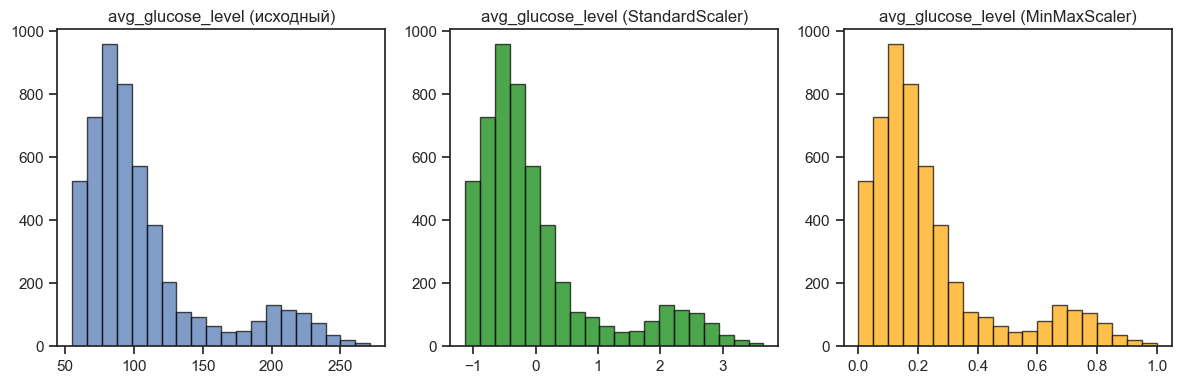

In [16]:
col_plot = 'avg_glucose_level'
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(X[col_plot], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title(f'{col_plot} (исходный)')
axes[1].hist(X_scaled_std_df[col_plot], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title(f'{col_plot} (StandardScaler)')
axes[2].hist(X_scaled_minmax_df[col_plot], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_title(f'{col_plot} (MinMaxScaler)')
plt.tight_layout()
plt.show()

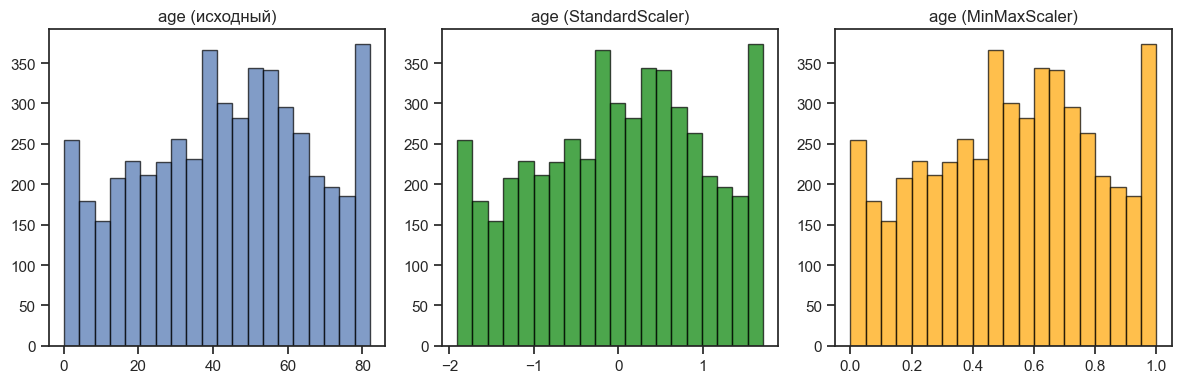

In [17]:
col_plot = 'age'
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(X[col_plot], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title(f'{col_plot} (исходный)')
axes[1].hist(X_scaled_std_df[col_plot], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title(f'{col_plot} (StandardScaler)')
axes[2].hist(X_scaled_minmax_df[col_plot], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_title(f'{col_plot} (MinMaxScaler)')
plt.tight_layout()
plt.show()

age: 0 выбросов (0.0%)
avg_glucose_level: 627 выбросов (12.3%)
bmi: 126 выбросов (2.5%)


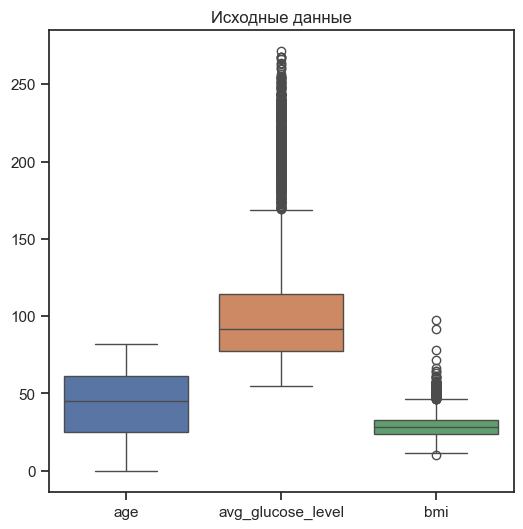

In [18]:
# Анализ выбросов (правило IQR: выброс — вне [Q1 - 1.5*IQR, Q3 + 1.5*IQR])
for col in show_cols:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((X[col] < (q1 - 1.5 * iqr)) | (X[col] > (q3 + 1.5 * iqr))).sum()
    print(f"{col}: {outliers} выбросов ({outliers/len(X)*100:.1f}%)")


fig, ax = plt.subplots(figsize=(6, 6))
sns.boxplot(data=X[show_cols], ax=ax)
ax.set_title('Исходные данные')
plt.show()

## Итог

Выполнены три этапа предобработки:
1. **Пропуски:** в `bmi` — замена медианой посредством SimpleImputer.
2. **Кодирование:** Label Encoding для `ever_married`, `Residence_type`; One-Hot Encoding для `work_type`, `gender`, `smoking_status`.
3. **Масштабирование:** применены StandardScaler и MinMaxScaler к числовым признакам.

Данные готовы для использования в моделях машинного обучения.